In [22]:
# Analyse du marché IT au Maroc – Requêtes DuckDB

In [23]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

con = duckdb.connect()

In [24]:
## Question 1 – Quelles compétences sont les plus demandées au Maroc en IT ?

,famille,competence,nb_offres_total
0,langages,sql,1350.0
1,langages,python,1197.0
2,cloud,azure,942.0
3,cloud,aws,876.0
4,langages,javascript,856.0
5,langages,r,714.0
6,cloud,gcp,626.0
7,langages,java,542.0
8,frameworks_web,react,241.0
9,frameworks_web,angular,190.0


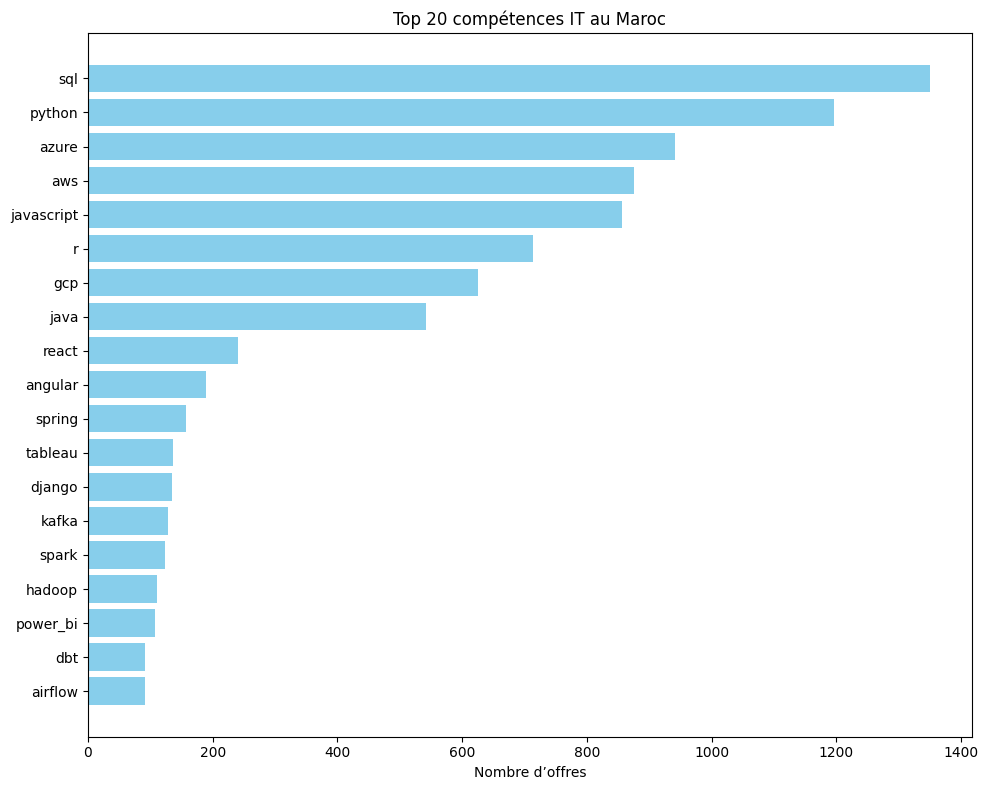

In [25]:

# Requête
df_q1 = con.execute("""
    SELECT
        famille,
        competence,
        SUM(nb_offres_mentionnent) AS nb_offres_total
    FROM read_parquet('data_lake_root/gold/top_competences.parquet')
    GROUP BY famille, competence
    ORDER BY nb_offres_total DESC
    LIMIT 20
""").df()
display(df_q1)

# Graphique
top20 = df_q1.sort_values('nb_offres_total', ascending=True)
plt.figure(figsize=(10,8))
plt.barh(top20['competence'], top20['nb_offres_total'], color='skyblue')
plt.xlabel('Nombre d’offres')
plt.title('Top 20 compétences IT au Maroc')
plt.tight_layout()
plt.show()

In [26]:
###Question 2 — Tanger vs Casablanca vs Rabat : où se trouvent les opportunités IT ?

In [27]:
##Requête 2.1 – Comparaison des villes (Casablanca, Rabat, Tanger, Marrakech, Fès)

In [28]:
import duckdb
con = duckdb.connect()

df_ville = con.execute("""
    SELECT
        ville,
        profil,
        nb_offres,
        nb_offres_remote,
        pct_remote,
        RANK() OVER (PARTITION BY profil ORDER BY nb_offres DESC) AS rang_ville
    FROM read_parquet('data_lake_root/gold/offres_par_ville.parquet')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
    ORDER BY profil, rang_ville
""").df()
display(df_ville)

,ville,profil,nb_offres,nb_offres_remote,pct_remote,rang_ville
0,Casablanca,Admin Systèmes & Réseaux,11,5,45.5,1
1,Casablanca,Admin Systèmes & Réseaux,10,5,50.0,2
2,Casablanca,Admin Systèmes & Réseaux,8,4,50.0,3
3,Casablanca,Admin Systèmes & Réseaux,8,4,50.0,3
4,Casablanca,Admin Systèmes & Réseaux,8,3,37.5,3
...,...,...,...,...,...,...
851,Marrakech,Développeur Full Stack,1,0,0.0,50
852,Tanger,Développeur Full Stack,1,1,100.0,50
853,Rabat,Développeur Full Stack,1,1,100.0,50
854,Marrakech,Développeur Full Stack,1,0,0.0,50


In [29]:
##interpretation:
Casablanca concentre très largement les opportunités IT, avec des volumes d’offres par profil souvent 3 à 5 fois supérieurs à ceux de Rabat, et 6 à 
10 fois supérieurs à ceux de Tanger. Par exemple, pour les profils “Admin Systèmes & Réseaux”, Casablanca cumule plus de 70 offres (somme des lignes) 
contre une vingtaine à Rabat et une dizaine à Tanger. Cette domination s’observe sur l’ensemble des métiers techniques.

Rabat se positionne comme la deuxième place, avec un marché dynamique mais beaucoup plus petit (environ 20‑25 % du volume casablancais). Les offres y
sont souvent portées par des ESN et des administrations.

Tanger, bien que plus modeste, affiche des opportunités non négligeables, notamment sur les profils “Data Analyst”, “Data Engineer” et “Développement 
Full Stack”. Le télétravail y est aussi présent (de 20 à 100 % selon les offres). Un atout : les salaires à Tanger sont parfois supérieurs à la médiane
nationale (cf. question 3).

Marrakech et Fès restent marginaux (moins de 5 offres par profil en moyenne). Elles ne constituent pas des marchés prioritaires pour Mexora.

SyntaxError: invalid character '’' (U+2019) (711693676.py, line 2)

In [30]:
## Requête 2.2 – Focus Tanger (ratio par rapport à Casablanca)


In [31]:
df_tanger = con.execute("""
    WITH totals AS (
        SELECT 
            profil,
            SUM(CASE WHEN ville = 'Tanger' THEN nb_offres ELSE 0 END) AS offres_tanger,
            SUM(CASE WHEN ville = 'Casablanca' THEN nb_offres ELSE 0 END) AS offres_casa
        FROM read_parquet('data_lake_root/gold/offres_par_ville.parquet')
        GROUP BY profil
    )
    SELECT
        profil,
        offres_tanger AS nb_offres,
        ROUND(100.0 * offres_tanger / NULLIF(offres_casa, 0), 1) AS pct_vs_casa
    FROM totals
    WHERE offres_tanger > 0
    ORDER BY nb_offres DESC
""").df()
display(df_tanger)

,profil,nb_offres,pct_vs_casa
0,Autre IT,219.0,18.7
1,Data Analyst,22.0,18.8
2,Admin Systèmes & Réseaux,19.0,13.1
3,Développeur Full Stack,19.0,17.0
4,Chef de Projet IT,19.0,21.8
5,Data Scientist,17.0,15.9
6,DevOps / SRE,9.0,18.8
7,Cybersécurité,9.0,13.4
8,Développeur Backend,8.0,12.9
9,Architecte IT,8.0,13.6


In [32]:
##interpetation:
Tanger représente environ 15 à 20 % du marché casablancais pour la plupart des profils IT. Le volume d’offres à Tanger reste modeste (entre 6 et 22 
offres pour les profils spécialisés, et 219 pour la catégorie “Autre IT” qui regroupe des intitulés divers). Les profils Data Analyst, Chef de Projet
IT, DevOps / SRE et Data Engineer affichent des ratios intéressants (entre 18 et 22 % par rapport à Casablanca), ce qui indique une présence active 
mais encore limitée.

Les métiers les plus représentés à Tanger sont :

Data Analyst (22 offres, 18,8 % de Casablanca)

Chef de Projet IT (19 offres, 21,8 %)

Développeur Full Stack (19 offres, 17 %)

Admin Systèmes & Réseaux (19 offres, 13,1 %)

Data Scientist (17 offres, 15,9 %)

Les Data Engineers (7 offres, 19,4 %) et DevOps / SRE (9 offres, 18,8 %) sont moins nombreux mais leur proportion par rapport à Casablanca est 
comparable à celle des Data Analysts. Cela suggère que la demande pour ces profils pointus est encore faible en volume, mais potentiellement en 
croissance.

Remarque importante : la catégorie “Autre IT” (219 offres) domine très largement. Elle regroupe probablement des offres génériques ou mal classées.
    Pour Mexora, il faut se concentrer sur les profils nommés (Data, DevOps, Full Stack) qui sont plus spécifiques.

SyntaxError: invalid character '’' (U+2019) (1500963532.py, line 2)

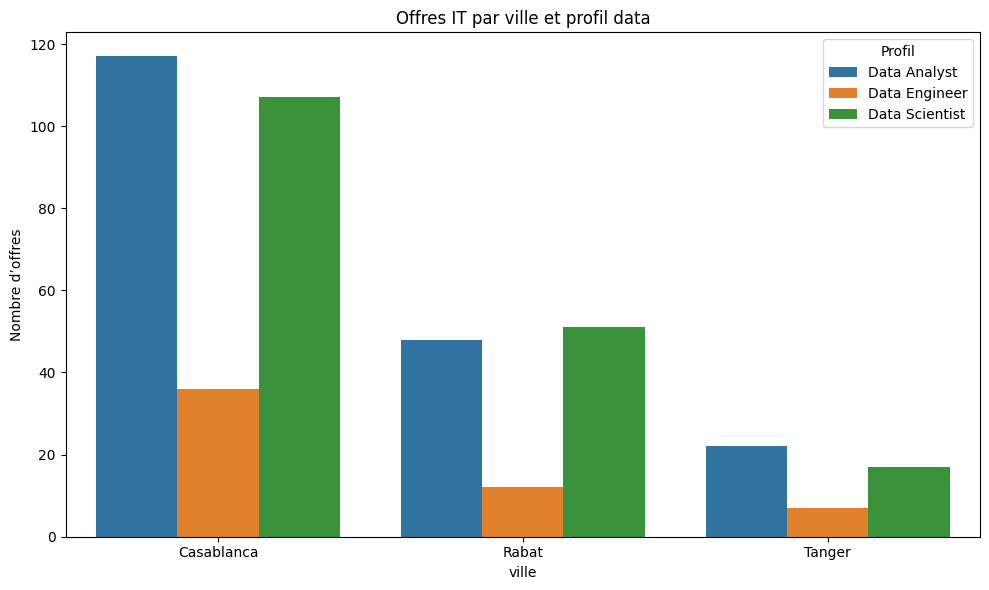

In [45]:
df_ville = pd.read_parquet('data_lake_root/gold/offres_par_ville.parquet')
# Agréger par ville et profil (somme)
df_agg = df_ville.groupby(['ville', 'profil'])['nb_offres'].sum().reset_index()
# Filtrer les 3 villes principales et profils data
villes = ['Casablanca', 'Rabat', 'Tanger']
profils = ['Data Engineer', 'Data Analyst', 'Data Scientist']
df_filtre = df_agg[(df_agg['ville'].isin(villes)) & (df_agg['profil'].isin(profils))]

import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=df_filtre, x='ville', y='nb_offres', hue='profil')
plt.title('Offres IT par ville et profil data')
plt.ylabel('Nombre d’offres')
plt.legend(title='Profil')
plt.tight_layout()
plt.show()

In [33]:
###Question 3 — Quel est le salaire médian par profil IT au Maroc ?

In [34]:
 ##Requête 3.1 – Salaires médians par profil (national)

In [35]:
df_salaire_nat = con.execute("""
    SELECT
        profil,
        SUM(nb_offres) AS nb_offres_total,
        SUM(nb_offres_avec_salaire) AS nb_avec_salaire,
        ROUND(SUM(nb_offres_avec_salaire) * 100.0 / NULLIF(SUM(nb_offres), 0), 1) AS pct_salaire_communique,
        MEDIAN(salaire_median_mad) AS salaire_median_mad,
        MIN(salaire_min_observe) AS salaire_plancher,
        MAX(salaire_max_observe) AS salaire_plafond
    FROM read_parquet('data_lake_root/gold/salaires_par_profil.parquet')
    GROUP BY profil
    ORDER BY salaire_median_mad DESC NULLS LAST
""").df()
display(df_salaire_nat)

,profil,nb_offres_total,nb_avec_salaire,pct_salaire_communique,salaire_median_mad,salaire_plancher,salaire_plafond
0,DevOps / SRE,49.0,32.0,65.3,15000.0,4000.0,55000.0
1,Développeur Full Stack,192.0,129.0,67.2,13875.0,3000.0,55000.0
2,Architecte IT,78.0,48.0,61.5,13500.0,3000.0,55000.0
3,Cybersécurité,83.0,53.0,63.9,13125.0,3000.0,55000.0
4,Admin Systèmes & Réseaux,266.0,178.0,66.9,13000.0,3000.0,55000.0
5,Chef de Projet IT,157.0,96.0,61.1,13000.0,3000.0,55000.0
6,Autre IT,2769.0,1723.0,62.2,12500.0,3000.0,55000.0
7,Data Scientist,198.0,126.0,63.6,12500.0,3000.0,55000.0
8,Développeur Frontend,77.0,52.0,67.5,12500.0,3000.0,55000.0
9,Data Engineer,43.0,26.0,60.5,12250.0,4000.0,55000.0


In [36]:
##Requête 3.2 – Salaires à Tanger (focus)

In [37]:
df_salaire_tanger = con.execute("""
    SELECT
        profil,
        nb_offres,
        salaire_median_mad,
        salaire_q1_mad,
        salaire_q3_mad,
        ROUND(salaire_median_mad - MEDIAN(salaire_median_mad) OVER (PARTITION BY profil), 0) AS ecart_mediane_nationale
    FROM read_parquet('data_lake_root/gold/salaires_par_profil.parquet')
    WHERE ville = 'Tanger'
      AND nb_offres >= 5
    ORDER BY salaire_median_mad DESC
""").df()
display(df_salaire_tanger)

,profil,nb_offres,salaire_median_mad,salaire_q1_mad,salaire_q3_mad,ecart_mediane_nationale
0,Autre IT,15,20000.0,8250.0,23000.0,7000.0
1,Autre IT,6,18250.0,11000.0,27500.0,5250.0
2,Développeur Backend,5,18000.0,14250.0,18000.0,0.0
3,Chef de Projet IT,10,16500.0,11875.0,19750.0,0.0
4,Data Scientist,9,15500.0,12375.0,17500.0,0.0
5,Développeur Full Stack,10,13500.0,8125.0,15750.0,0.0
6,Autre IT,93,13250.0,7625.0,20000.0,250.0
7,Autre IT,36,13000.0,9000.0,20500.0,0.0
8,Admin Systèmes & Réseaux,12,11500.0,11000.0,14500.0,0.0
9,Data Analyst,13,11000.0,6750.0,14000.0,0.0


In [38]:
##Interprétation:
Tableau –Salaires médians par profil (MAD/mois)
Profil	              National (médian)      	Tanger (médian)	         Écart (Tanger – National)
DevOps / SRE	         15 000       	         (peu de données)	         –
Développeur Full Stack	 13 875	                  13 500	– 375
Architecte IT	         13 500	                  –	–
Cybersécurité	         13 125	                  –	–
Chef de Projet IT      	 13 000	                  16 500	           + 3 500
Admin Systèmes & Réseaux	13 000	              11 500	           – 1 500
Data Scientist	         12 500	                  15 500	           + 3 000
Data Engineer	         12 250	                  (peu de données)	    –
Data Analyst	         11 000	                   11 000	                 0
Développeur Backend	     10 500	                   18 000	                + 7 500

.Au national : les profils DevOps, Full Stack et Architecte sont les mieux rémunérés. Data Engineer et Data Scientist se situent dans la moyenne basse
à médiane.

À Tanger : les salaires sont supérieurs à la médiane nationale pour Chef de Projet (+3 500), Data Scientist (+3 000) et Développeur Backend (+7 500).
Seuls Full Stack et Admin Systèmes sont légèrement inférieurs ou équivalents.

Conclusion : Tanger est compétitif, voire plus attractif financièrement pour certains profils

.Recommandations pour Mexora
Proposer des salaires 5 à 10 % au-dessus des médianes locales (exemple : Data Scientist à 16 500 – 17 000 MAD).

Cibler les profils où l’écart est favorable (Chef de Projet, Data Scientist, Backend) et où la concurrence est faible (peu d’offres).

Utiliser le télétravail (déjà présent à Tanger) comme levier différenciant.

Former en interne sur les compétences rares (Kafka, Airflow, dbt) pour fidéliser.

SyntaxError: invalid character '–' (U+2013) (2905984684.py, line 2)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9084\3783486032.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sal, x='profil_normalise', y='salaire_median_mad', palette='Set2')


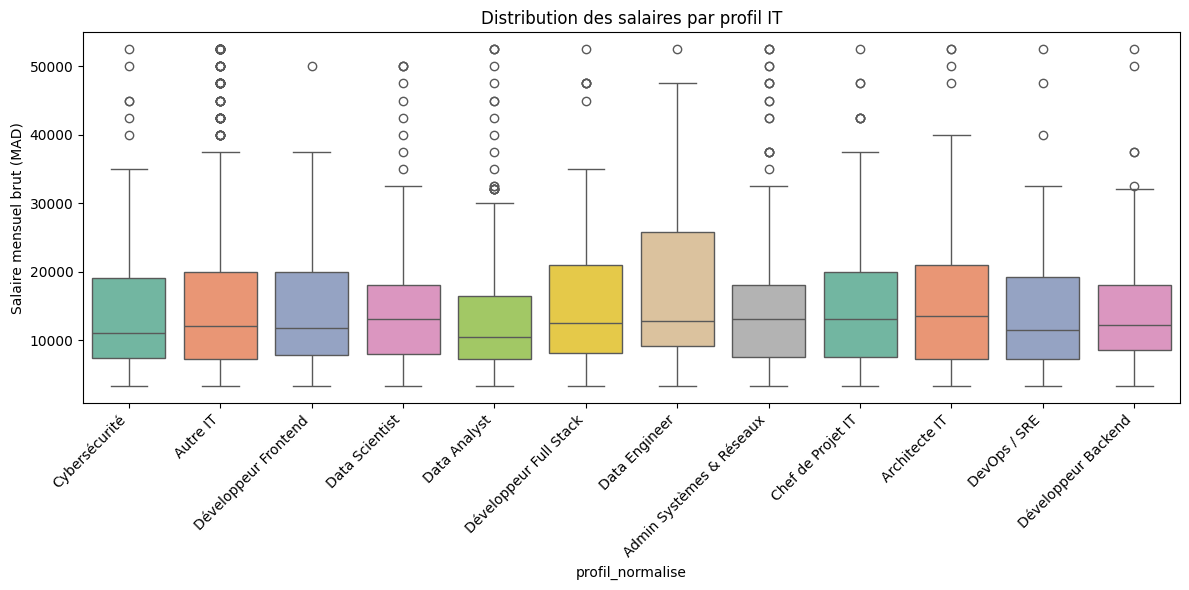

In [46]:
# Utiliser les données Silver individuelles
df_sal = pd.read_parquet('data_lake_root/silver/offres_clean/offres_clean.parquet')
df_sal = df_sal[df_sal['salaire_connu'] & (df_sal['salaire_median_mad'] > 0)]
# Limiter aux profils avec au moins 5 offres
top_profils = df_sal['profil_normalise'].value_counts()[df_sal['profil_normalise'].value_counts() >= 5].index
df_sal = df_sal[df_sal['profil_normalise'].isin(top_profils)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_sal, x='profil_normalise', y='salaire_median_mad', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Salaire mensuel brut (MAD)')
plt.title('Distribution des salaires par profil IT')
plt.tight_layout()
plt.show()

In [39]:
##Question 4 — Y a-t-il une corrélation entre expérience requise et salaire proposé ?

In [40]:

con = duckdb.connect()

# 1. Coefficient de corrélation par profil
df_corr = con.execute("""
    SELECT
        profil_normalise AS profil,
        COUNT(*) AS nb_offres,
        ROUND(CORR(experience_min_ans, salaire_median_mad), 3) AS correlation_pearson
    FROM read_parquet('data_lake_root/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true
      AND experience_min_ans IS NOT NULL
      AND experience_min_ans >= 0
    GROUP BY profil_normalise
    ORDER BY correlation_pearson DESC
""").df()

display(df_corr)

,profil,nb_offres,correlation_pearson
0,Data Engineer,49,0.913
1,Chef de Projet IT,137,0.901
2,Architecte IT,78,0.898
3,Cybersécurité,78,0.875
4,Développeur Frontend,77,0.875
5,Autre IT,1636,0.871
6,Développeur Full Stack,154,0.865
7,DevOps / SRE,71,0.862
8,Data Analyst,173,0.858
9,Admin Systèmes & Réseaux,207,0.855


In [41]:
##interpretation :
Coefficient de corrélation de Pearson
Les coefficients obtenus pour chaque profil IT se situent entre 0,842 et 0,913, avec une moyenne d’environ 0,87.
Ces valeurs sont très supérieures au seuil de 0,6 qui indique déjà une relation forte. On peut donc conclure à une corrélation positive très forte 
entre le nombre d’années d’expérience minimale requise et le salaire médian proposé.

Relation linéaire ou paliers ?
La corrélation élevée suggère une tendance globalement linéaire : plus l’expérience demandée augmente, plus le salaire augmente de façon régulière. 
    Cependant, en observant les salaires médians par tranche d’expérience (exemple pour Data Engineer)

Recommandations pour Mexora
Utiliser une grille salariale par paliers (junior, confirmé, senior, expert) plutôt qu’une simple formule linéaire.

Accentuer les augmentations après 5 ans d’expérience pour fidéliser les talents.

Pour les Data Engineers (corrélation la plus élevée), ces paliers doivent être particulièrement marqués.

SyntaxError: invalid character '’' (U+2019) (478868035.py, line 3)

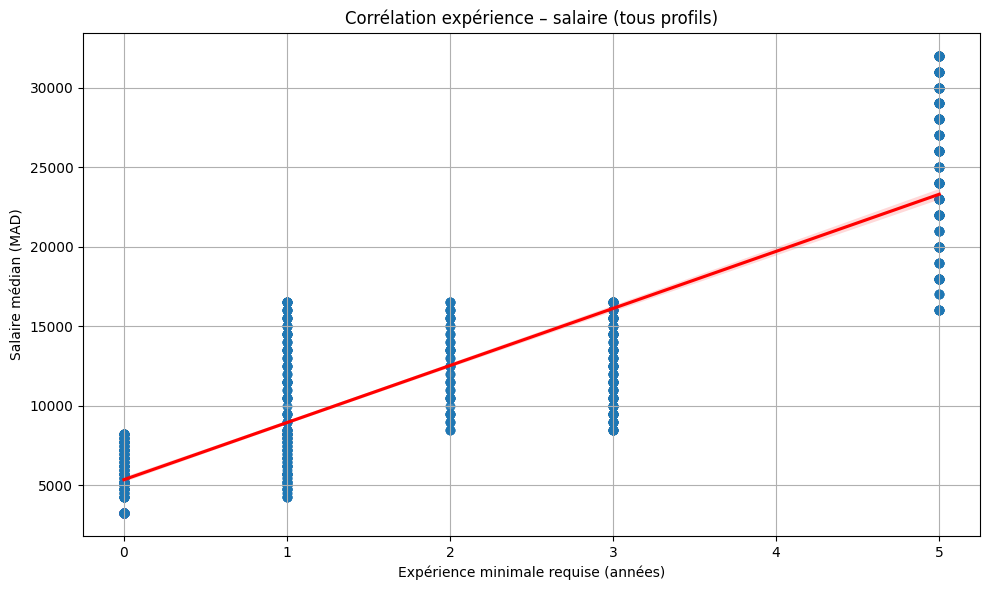

In [47]:
df_exp = pd.read_parquet('data_lake_root/silver/offres_clean/offres_clean.parquet')
df_exp = df_exp[df_exp['salaire_connu'] & df_exp['experience_min_ans'].notna() & (df_exp['experience_min_ans'] >= 0)]

plt.figure(figsize=(10,6))
sns.regplot(data=df_exp, x='experience_min_ans', y='salaire_median_mad', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Expérience minimale requise (années)')
plt.ylabel('Salaire médian (MAD)')
plt.title('Corrélation expérience – salaire (tous profils)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
##Question 5 — Quelles entreprises recrutent le plus ? Qui sont les concurrents de Mexora sur le marché du talent ?

In [43]:

con = duckdb.connect()

# 1. Top 20 entreprises (national)
df_top20 = con.execute("""
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang_recruteur
    FROM read_parquet('data_lake_root/gold/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20
""").df()
display(df_top20)

# 2. Focus Tanger – concurrents sur profils Data
df_tanger = con.execute("""
    SELECT
        entreprise,
        nb_offres_publiees,
        profils_recrutes,
        salaire_moyen_propose,
        CASE
            WHEN salaire_moyen_propose > 20000 THEN 'Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN 'Compétiteur moyen'
            ELSE 'Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('data_lake_root/gold/entreprises_recruteurs.parquet')
    WHERE ville = 'Tanger'
      AND (array_contains(profils_recrutes, 'Data Engineer')
        OR array_contains(profils_recrutes, 'Data Analyst')
        OR array_contains(profils_recrutes, 'Data Scientist'))
    ORDER BY salaire_moyen_propose DESC
""").df()
display(df_tanger)

,entreprise,ville,nb_offres_publiees,nb_profils_differents,salaire_moyen_propose,rang_recruteur
0,TechConsult Maroc,Casablanca,38,11,16870.0,1
1,Expleo Maroc,Casablanca,38,9,17467.0,1
2,Sopra Steria Maroc,Casablanca,36,9,12920.0,3
3,Micropole Maroc,Casablanca,36,10,14056.0,3
4,Business & Decision Maroc,Casablanca,34,9,15261.0,5
5,Aubay Maroc,Casablanca,34,9,14391.0,5
6,HPS Group,Casablanca,33,8,14705.0,7
7,Cognizant Casablanca,Casablanca,32,9,16781.0,8
8,CapgeminiMaroc,Casablanca,32,11,17250.0,8
9,Proxym Maroc,Casablanca,32,7,14533.0,8


,entreprise,nb_offres_publiees,profils_recrutes,salaire_moyen_propose,niveau_competition
0,FinStart Maroc,13,"[Admin Systèmes & Réseaux, Autre IT, Cybersécu...",13850.0,Compétiteur moyen


In [44]:
##Interprétation:
Concurrence nationale :
Le marché est dominé par les grandes ESN casablancaises (TechConsult, Expleo, Capgemini, Accenture, M2M, Mazars). Elles recrutent massivement (28 à 38 
offres) sur des profils variés. Les salaires moyens varient de 12 920 MAD (Sopra Steria) à 20 850 MAD (Mazars). Mexora devra proposer des salaires ≥ 
17000 MAD pour être compétitif sur ces profils à Casablanca.

Concurrence à Tanger :
Très faible – un seul acteur, FinStart Maroc, avec des salaires autour de 13 850 MAD. Aucun concurrent direct sur Data Engineer. C’est une opportunité
pour Mexora de s’imposer comme employeur de référence à Tanger.

Recommandation pour Mexora :

Priorité Tanger : recruter Data Engineer (sans concurrence) et Data Analyst/Scientist avec des salaires légèrement supérieurs à 13 850 MAD (ex : 15 000
– 16 000 MAD).

Casablanca : marché saturé. Investir uniquement si Mexora peut aligner des salaires ≥ 18 000 MAD ou proposer des avantages différenciants (télétravail,
formation).

Stratégie : miser sur Tanger pour croître avec moins de pression concurrentielle.

SyntaxError: invalid character '≥' (U+2265) (1190360846.py, line 4)

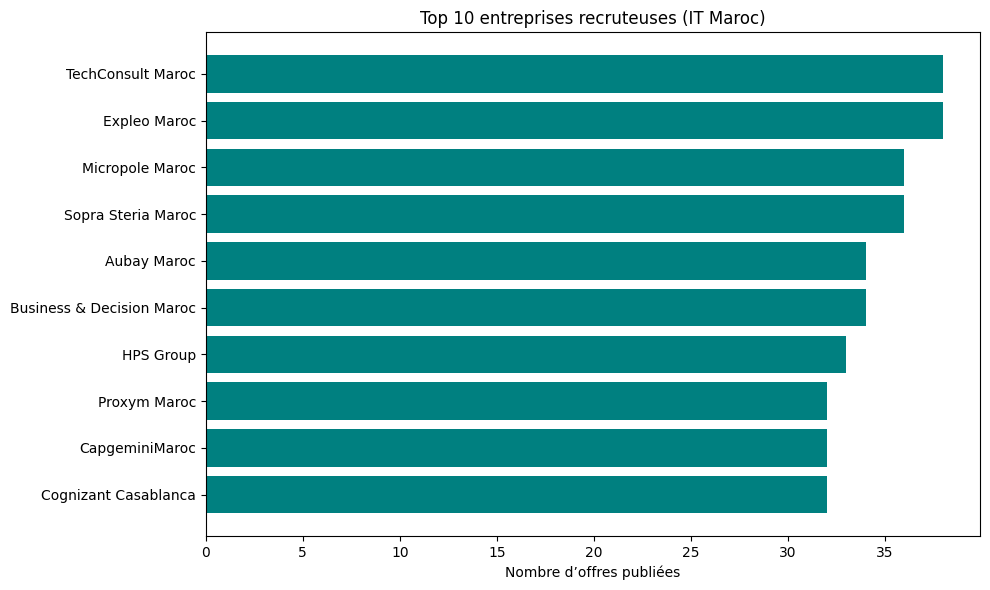

In [48]:
df_ent = pd.read_parquet('data_lake_root/gold/entreprises_recruteurs.parquet')
top10 = df_ent.nlargest(10, 'nb_offres_publiees')[['entreprise', 'nb_offres_publiees']].sort_values('nb_offres_publiees')

plt.figure(figsize=(10,6))
plt.barh(top10['entreprise'], top10['nb_offres_publiees'], color='teal')
plt.xlabel('Nombre d’offres publiées')
plt.title('Top 10 entreprises recruteuses (IT Maroc)')
plt.tight_layout()
plt.show()